# MNIST-Add-Cov: looking at the inputs

`features` is a `[2, 28, 28]` tensor: digit 1 on channel 0, digit 2 on channel 1
(channel stacking, matching `data.num_covariates=2` and `IntCEMMNISTEncoder`).

Observed concepts are `[A1, H1, H2]`; `A2` and `X` are oracle-only and never enter
the bottleneck.

In [1]:
import matplotlib.pyplot as plt
import torch
from omegaconf import OmegaConf

from datasets.MNIST_add_cov_dataset import (
    get_MNIST_add_cov_datasets,
    get_mnist_add_cov_concept_names,
    get_mnist_add_cov_oracle_names,
)

# The run config, read straight off the yaml so the notebook sees the same
# split sizes / planted function / corruption as training does.
config_data = OmegaConf.merge(
    OmegaConf.load("configs/data/data_defaults.yaml"),
    OmegaConf.load("configs/data/mnist_add.yaml"),
)
config_data.data_path = "datasets/"   # local path; the cluster uses work/Data/
print(OmegaConf.to_yaml(config_data))

data_path: datasets/
incomplete_dir: incomplete_data/
defaults:
- data_defaults
dataset: MNIST-Add-Cov
num_classes: 8
num_concepts: 3
num_residuals: 1
num_covariates: 2
train_dataset_size: 12000
val_dataset_size: 2400
test_dataset_size: 10000
val_percent: 0.2
planted_function: xor
corruption: none
corruption_strength: 0.0
corruption_probability: 1.0
test_corruption: none
test_corruption_strength: 0.0
test_corruption_probability: 1.0
save_predicted_concepts_residuals: false
save_residual_channel: false
save_concept_and_residual_channel: false



In [2]:
trainset, valset, testset = get_MNIST_add_cov_datasets(config_data, seed=0)
concept_names = get_mnist_add_cov_concept_names()
oracle_names = get_mnist_add_cov_oracle_names()
print(len(trainset), len(valset), len(testset))
print(concept_names, "| oracle:", oracle_names)

12000 2400 10000
['A1::digit1_is_odd', 'H1::digit1_ge_6', 'H2::digit2_ge_6'] | oracle: ['A2::digit2_is_odd', 'X::planted_hidden_function']


## One sample

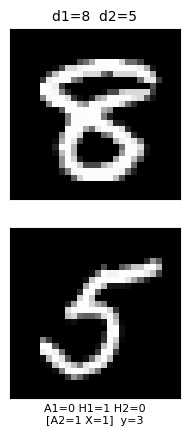

In [3]:
def show_sample(dataset, index, ax_pair=None):
    """Plot both channels of one sample, titled with its digits and labels."""
    item = dataset[index]
    features = item["features"]                     # [2, 28, 28]
    a1, h1, h2 = item["concepts"].tolist()
    a2, x = item["hidden_concepts"].tolist()
    d1, d2 = item["digit_labels"].tolist()

    if ax_pair is None:
        _, ax_pair = plt.subplots(2, 1, figsize=(2.0, 4.6))
    for channel, ax in enumerate(ax_pair):
        ax.imshow(features[channel], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
    ax_pair[0].set_title(f"d1={d1}  d2={d2}", fontsize=10)
    ax_pair[1].set_xlabel(
        f"A1={a1:.0f} H1={h1:.0f} H2={h2:.0f}\n"
        f"[A2={a2:.0f} X={x:.0f}]  y={int(item['labels'])}",
        fontsize=8,
    )
    return ax_pair


show_sample(trainset, 0)
plt.tight_layout()
plt.show()

## A grid of samples

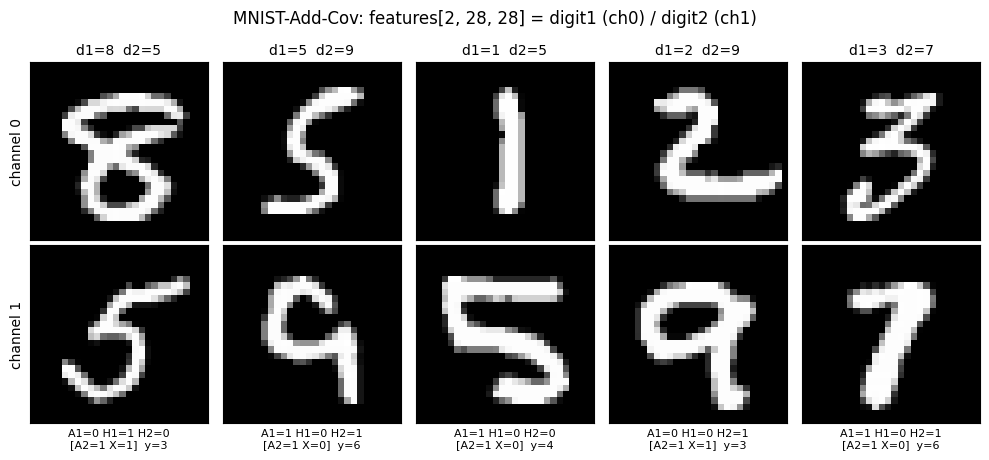

In [4]:
def show_samples(dataset, indices):
    fig, axes = plt.subplots(2, len(indices), figsize=(2.0 * len(indices), 4.6))
    for column, index in enumerate(indices):
        show_sample(dataset, index, ax_pair=axes[:, column])
    axes[0, 0].set_ylabel("channel 0")
    axes[1, 0].set_ylabel("channel 1")
    fig.suptitle("MNIST-Add-Cov: features[2, 28, 28] = digit1 (ch0) / digit2 (ch1)")
    fig.tight_layout()
    return fig


show_samples(trainset, range(5))
plt.show()

## Corrupted inputs

`corruption` is applied to digit 1 only, so this is the channel whose concepts
(`A1`, `H1`) get harder to read while digit 2 stays clean.

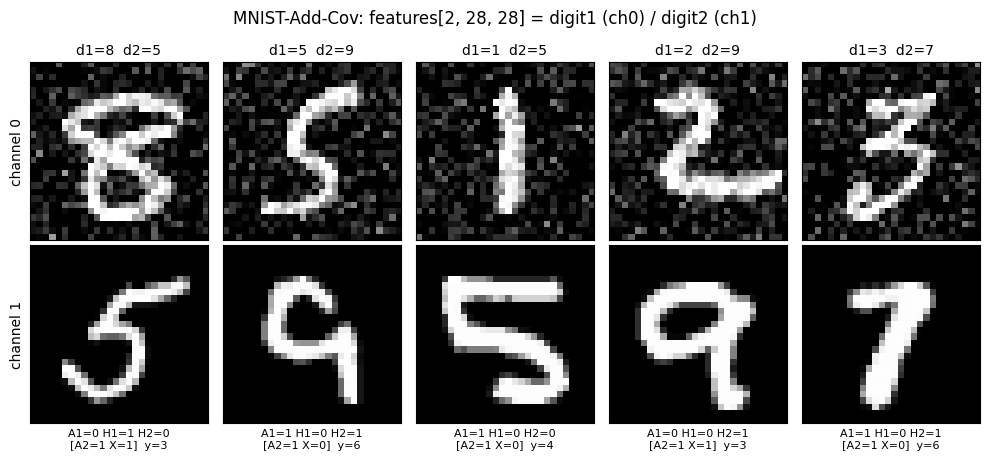

In [5]:
corrupted_config = OmegaConf.merge(
    config_data, {"corruption": "gaussian", "corruption_strength": 0.2}
)
corrupted_trainset, _, _ = get_MNIST_add_cov_datasets(corrupted_config, seed=0)

show_samples(corrupted_trainset, range(5))
plt.show()